In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression
import joblib

from google.colab import files
uploaded = files.upload()

df=pd.read_csv('online_vs_offline_learning_dataset.csv')




Saving online_vs_offline_learning_dataset.csv to online_vs_offline_learning_dataset (1).csv


In [ ]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

  Learning_Mode  Subject  Study_Hours  Retention_Score  Focus_Level  \
0       Offline  English          7.7               51           96   
1       Offline  English          6.2               90           82   
2        Online  English          1.2               75           66   
3        Online     Math          6.5               80           64   
4        Online  English          5.5               95           58   

   Exam_Score  
0          70  
1          81  
2          71  
3          77  
4          78  
(1000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   in

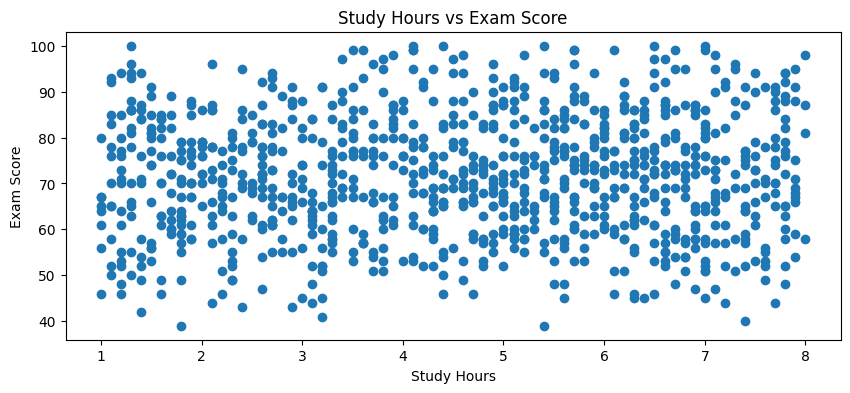

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(df['Study_Hours'], df['Exam_Score'])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.show()


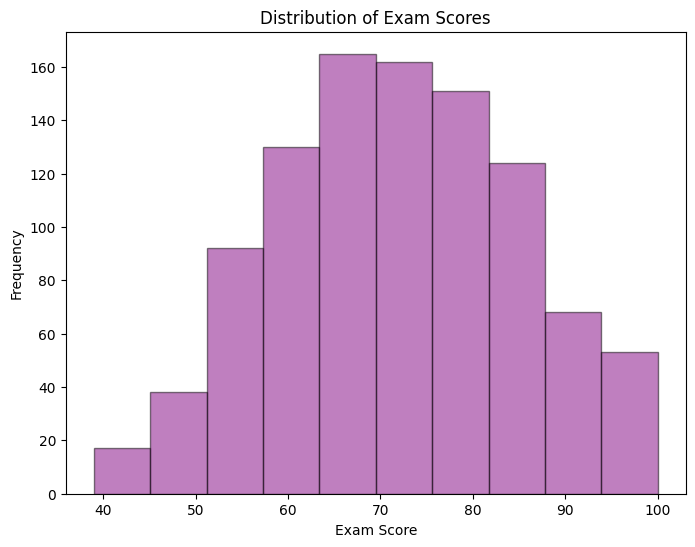

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['Exam_Score'], bins=10, edgecolor='black', color='purple',alpha=0.5)
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam Scores')
plt.show()

In [ ]:
le=LabelEncoder()
df['Learning_Mode_Encoded']=le.fit_transform(df['Learning_Mode'])
df = pd.get_dummies(df, columns=['Subject'], drop_first=True)


In [ ]:
X=df.drop(['Learning_Mode','Exam_Score'],axis=1)
y=df['Exam_Score']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("R2_SCore:",r2)
print("Mean_squared_error:",mse)



R2_SCore: 0.9401876407167528
Mean_squared_error: 9.973374465960505
